In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.nn.functional import conv2d, max_pool2d, cross_entropy

np.random.seed(42)
torch.manual_seed(42)
plt.rc("figure", dpi=110)

# Exercise 3 — PyTorch, Dropout, Parametric ReLU & Convolutional Networks

In [2]:
# ---- Run configuration ----
# Reduced for a CPU-friendly, fully-executed notebook.
# Increase these for full reproduction of the sheet (full MNIST, ~100 epochs).
# The GPU is used automatically whenever one is available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 100
train_subset_size = 30000
test_subset_size = 5000

fc_epochs = 100   # fully-connected models (Tasks 1-3)
cnn_epochs = 100   # convolutional models (Task 4)

learning_rate = 1e-3

Using device: cuda


In [3]:
# ---- MNIST data ----
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,)),
    ]
)

full_train = datasets.MNIST("./mnist_data", download=True, train=True, transform=transform)
full_test = datasets.MNIST("./mnist_data", download=True, train=False, transform=transform)

# Deterministic subsets keep the notebook runnable on CPU.
train_dataset = Subset(full_train, range(train_subset_size))
test_dataset = Subset(full_test, range(test_subset_size))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# One sample test image, reused for the convolution plots in Task 4.
sample_image, sample_label = full_test[0]

In [4]:
def init_weights(shape):
    # Kaiming He initialization (good for ReLU-style activations).
    std = np.sqrt(2.0 / shape[0])
    w = torch.randn(size=shape, device=device) * std
    w.requires_grad = True
    return w

def rectify(x):
    # Rectified Linear Unit (ReLU).
    return torch.max(torch.zeros_like(x), x)

def dropout(x, p_drop):
    # From-scratch inverted dropout (no torch.nn.functional.dropout).
    # With probability p_drop an element is zeroed; survivors are rescaled by 1/(1-p_drop)
    # so the expected activation is unchanged.
    if not 0.0 < p_drop < 1.0:
        return x
    keep_mask = torch.bernoulli(torch.full_like(x, 1.0 - p_drop))
    return x * keep_mask / (1.0 - p_drop)

def prelu(x, a):
    # Parametric ReLU: x for x > 0, a*x for x <= 0, with learnable slope a.
    return torch.where(x > 0, x, a * x)

def conv_features(images, conv_weights, p_drop):
    # Apply a stack of (conv -> ReLU -> 2x2 max-pool -> dropout) blocks.
    activations = images
    for weight in conv_weights:
        activations = max_pool2d(rectify(conv2d(activations, weight)), (2, 2))
        activations = dropout(activations, p_drop)
    return activations

class RMSprop(optim.Optimizer):
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        super().__init__(params, dict(lr=lr, alpha=alpha, eps=eps))

    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]
                if len(state) == 0:
                    state["square_avg"] = torch.zeros_like(p.data)
                square_avg = state["square_avg"]
                alpha = group["alpha"]
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group["eps"])
                p.data.addcdiv_(grad, avg, value=-group["lr"])

def evaluate(forward):
    # Mean test loss and classification error rate. forward(images, train=False)
    # disables dropout so the evaluation model is deterministic.
    total_loss = 0.0
    n_wrong = 0
    n_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = forward(images, False)
            total_loss += float(cross_entropy(logits, labels, reduction="sum"))
            predictions = logits.argmax(dim=1)
            n_wrong += int((predictions != labels).sum())
            n_total += labels.shape[0]
    return total_loss / n_total, n_wrong / n_total

def train_classifier(forward, params, n_epochs, lr):
    # Generic mini-batch training loop shared by every model below.
    optimizer = RMSprop(params, lr=lr)
    train_loss_history = []
    test_loss_history = []
    test_error_history = []
    for epoch in range(n_epochs + 1):
        batch_losses = []
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = forward(images, True)
            optimizer.zero_grad()
            loss = cross_entropy(logits, labels, reduction="mean")
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss_history.append(float(np.mean(batch_losses)))
        epoch_test_loss, epoch_test_error = evaluate(forward)
        test_loss_history.append(epoch_test_loss)
        test_error_history.append(epoch_test_error)
    return train_loss_history, test_loss_history, test_error_history

<div style="color: green; font-weight: bold">

The dropout implementation is mathematically correct and equivalent to the sample solution, but you use a different masking strategy. Compared to the sample solution, which uses a boolean mask and in-place zeroing, your version uses multiplicative masking.
</div>

## Task 1 — Introduction: a two-hidden-layer baseline

A fully-connected network `784 -> 625 -> 625 -> 10` with ReLU hidden activations,
trained with cross-entropy loss and the reduced `RMSprop` optimizer. This reproduces
the structure of the provided `intro.py`.

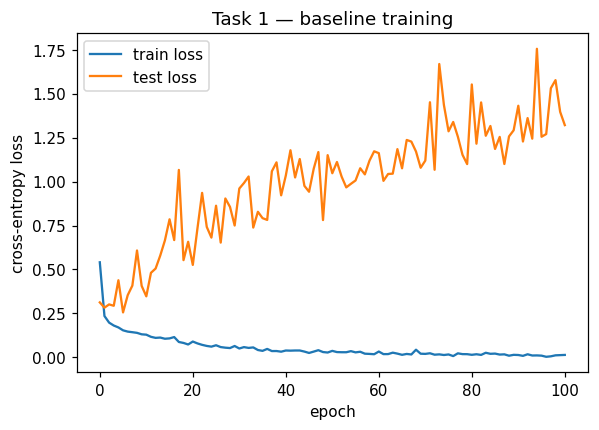

Task 1 baseline — final test error: 0.0320 (96.80% accuracy)


In [5]:
# ---- Task 1: baseline fully-connected network ----
def baseline_model(x, w_h, w_h2, w_o):
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    return h2 @ w_o

torch.manual_seed(0)
np.random.seed(0)
baseline_w_h = init_weights((784, 625))
baseline_w_h2 = init_weights((625, 625))
baseline_w_o = init_weights((625, 10))
baseline_params = [baseline_w_h, baseline_w_h2, baseline_w_o]

def baseline_forward(images, train):
    flat = images.reshape(images.shape[0], 784)
    return baseline_model(flat, baseline_w_h, baseline_w_h2, baseline_w_o)

baseline_train_loss, baseline_test_loss, baseline_error_history = train_classifier(
    baseline_forward, baseline_params, fc_epochs, learning_rate
)
baseline_test_error = baseline_error_history[-1]

_fig, _ax = plt.subplots(figsize=(6, 4))
_ax.plot(baseline_train_loss, label="train loss")
_ax.plot(baseline_test_loss, label="test loss")
_ax.set_xlabel("epoch")
_ax.set_ylabel("cross-entropy loss")
_ax.set_title("Task 1 — baseline training")
_ax.legend()
plt.show()

print(f"Task 1 baseline — final test error: {baseline_test_error:.4f} "
      f"({100 * (1 - baseline_test_error):.2f}% accuracy)")

## Task 2 — Dropout

**How it works.** During training, `dropout(X, p_drop)` independently zeroes each
element of `X` with probability `p_drop` and rescales the survivors by `1/(1-p_drop)`
(*inverted dropout*), so the expected value of each activation is preserved. We apply
dropout to the input of each of the three linear layers.

**Why it reduces overfitting.** Randomly removing units stops the network from relying
on specific co-adapted neurons; each unit must learn features that are useful on their
own. This acts like training an ensemble of thinned sub-networks that share weights,
which improves generalization.

**Why a different configuration at test time.** Dropout injects noise that we only want
while *learning*. For evaluation we disable dropout (here `p_drop = 0`) so the model is
deterministic and uses all units; the `1/(1-p_drop)` rescaling during training is what
keeps the activation magnitudes consistent between the two regimes. The resulting test
error is compared against the Task 1 baseline in the final overview.

In [6]:
# ---- Task 2: dropout network ----
def dropout_model(x, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    # Same fully-connected layers as Task 1, with dropout on the input of each layer.
    h = rectify(dropout(x, p_drop_input) @ w_h)
    h2 = rectify(dropout(h, p_drop_hidden) @ w_h2)
    return dropout(h2, p_drop_hidden) @ w_o

torch.manual_seed(0)
np.random.seed(0)
dropout_w_h = init_weights((784, 625))
dropout_w_h2 = init_weights((625, 625))
dropout_w_o = init_weights((625, 10))
dropout_params = [dropout_w_h, dropout_w_h2, dropout_w_o]
dropout_p_input = 0.2
dropout_p_hidden = 0.5

def dropout_forward(images, train):
    flat = images.reshape(images.shape[0], 784)
    if train:
        return dropout_model(
            flat, dropout_w_h, dropout_w_h2, dropout_w_o, dropout_p_input, dropout_p_hidden
        )
    # Evaluation: dropout disabled.
    return dropout_model(flat, dropout_w_h, dropout_w_h2, dropout_w_o, 0.0, 0.0)

dropout_train_loss, dropout_test_loss, dropout_error_history = train_classifier(
    dropout_forward, dropout_params, fc_epochs, learning_rate
)
dropout_test_error = dropout_error_history[-1]
print(f"Task 2 dropout — final test error: {dropout_test_error:.4f}")

Task 2 dropout — final test error: 0.0818


<div style="color: green; font-weight: bold">
This implementation is correct and functionally equivalent to the sample solution. 
</div>

## Task 3 — Parametric ReLU

Instead of a fixed ReLU we use `PReLU(x) = x` for `x > 0` and `a*x` for `x <= 0`, with a
**learnable** slope `a` (one per hidden unit, initialized to 0.25). The slope tensors are
added to the parameter list so `RMSprop` optimizes them jointly with the weights.

In [7]:
# ---- Task 3: parametric ReLU network ----
def prelu_model(x, w_h, w_h2, w_o, a1, a2):
    h = prelu(x @ w_h, a1)
    h2 = prelu(h @ w_h2, a2)
    return h2 @ w_o

torch.manual_seed(0)
np.random.seed(0)
prelu_w_h = init_weights((784, 625))
prelu_w_h2 = init_weights((625, 625))
prelu_w_o = init_weights((625, 10))
# Learnable PReLU slopes (one per hidden unit), included in the params list.
prelu_a1 = torch.full((625,), 0.25, device=device, requires_grad=True)
prelu_a2 = torch.full((625,), 0.25, device=device, requires_grad=True)
prelu_params = [prelu_w_h, prelu_w_h2, prelu_w_o, prelu_a1, prelu_a2]

def prelu_forward(images, train):
    flat = images.reshape(images.shape[0], 784)
    return prelu_model(flat, prelu_w_h, prelu_w_h2, prelu_w_o, prelu_a1, prelu_a2)

prelu_train_loss, prelu_test_loss, prelu_error_history = train_classifier(
    prelu_forward, prelu_params, fc_epochs, learning_rate
)
prelu_test_error = prelu_error_history[-1]
print(f"Task 3 PReLU — final test error: {prelu_test_error:.4f}")
print(f"Task 3 PReLU — learned slope a1 mean: {prelu_a1.mean().item():.4f} "
      f"(started at 0.2500)")

Task 3 PReLU — final test error: 0.0396
Task 3 PReLU — learned slope a1 mean: 0.2212 (started at 0.2500)


## Task 4 — Convolutional network (LeNet-like)

We replace the first hidden layer with three convolutional blocks, each
`rectify(conv2d(...))` followed by `2x2` max-pooling and dropout:

| layer | filters f | in-channels | kernel |
|------:|----------:|------------:|:------:|
| conv1 |        32 |           1 |  5×5   |
| conv2 |        64 |          32 |  5×5   |
| conv3 |       128 |          64 |  3×3   |

**Output-pixel count (Task 4.2), derived in code.** Starting from `28×28`:
conv1 → `24×24` → pool `12×12`; conv2 → `8×8` → pool `4×4`; conv3 → `2×2` → pool `1×1`.
With 128 filters that is `128·1·1 = 128` features. Rather than hard-code this, the cell
below runs the conv stack on a dummy input and reads off the flattened size, then sets
`w_h2 = init_weights((n_output_pixels, 625))` and a `625 -> 10` pre-softmax layer.

In [8]:
# ---- Task 4: convolutional LeNet-like network ----
torch.manual_seed(0)
np.random.seed(0)

# weight shape is (f, pic_in, k_x, k_y), per the sheet's init_weights((f, pic_in, k_x, k_y)).
cnn_conv_w1 = init_weights((32, 1, 5, 5))
cnn_conv_w2 = init_weights((64, 32, 5, 5))
cnn_conv_w3 = init_weights((128, 64, 3, 3))
cnn_conv_weights = [cnn_conv_w1, cnn_conv_w2, cnn_conv_w3]

# Task 4.2: determine the number of output pixels of the conv stack in code.
with torch.no_grad():
    _probe = conv_features(torch.zeros(1, 1, 28, 28, device=device), cnn_conv_weights, 0.0)
cnn_flat_features = int(_probe.reshape(1, -1).shape[1])

cnn_w_h2 = init_weights((cnn_flat_features, 625))
cnn_w_o = init_weights((625, 10))
cnn_p_drop = 0.2
cnn_params = cnn_conv_weights + [cnn_w_h2, cnn_w_o]

def cnn_forward(images, train):
    p = cnn_p_drop if train else 0.0
    features = conv_features(images.reshape(-1, 1, 28, 28), cnn_conv_weights, p)
    flat = features.reshape(features.shape[0], -1)
    hidden = dropout(rectify(flat @ cnn_w_h2), p)
    return hidden @ cnn_w_o

cnn_train_loss, cnn_test_loss, cnn_error_history = train_classifier(
    cnn_forward, cnn_params, cnn_epochs, learning_rate
)
cnn_test_error = cnn_error_history[-1]
print(f"Task 4 CNN — flattened conv features (output pixels): {cnn_flat_features}")
print(f"Task 4 CNN — final test error: {cnn_test_error:.4f} "
      f"({100 * (1 - cnn_test_error):.2f}% accuracy)")

Task 4 CNN — flattened conv features (output pixels): 128
Task 4 CNN — final test error: 0.0554 (94.46% accuracy)


### Task 4.2 — Visualizing the first convolutional layer

Below: one test image, its convolution with the first three filters of conv1, and the
corresponding `5×5` filter weights.

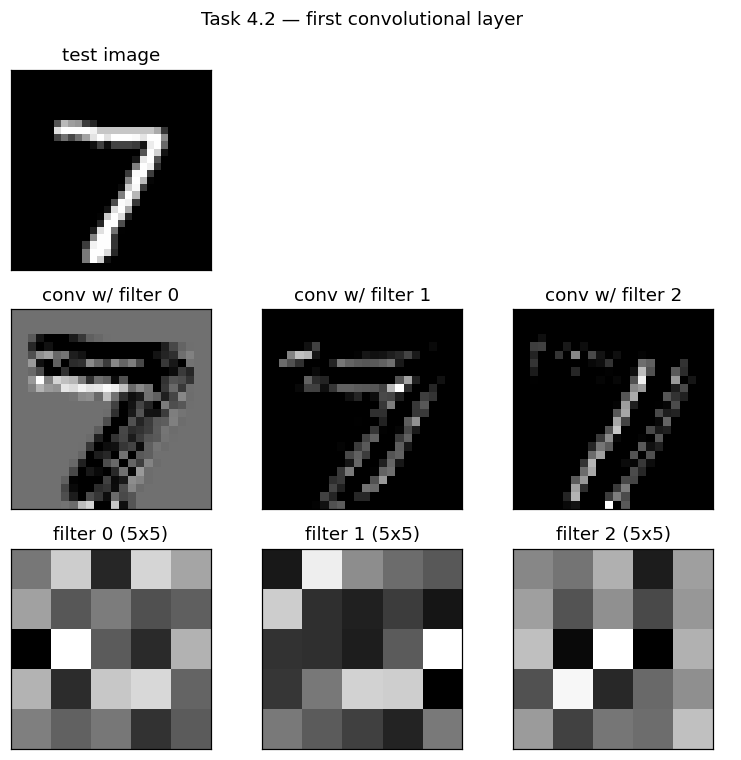

In [9]:
# ---- Task 4.2: visualize a test image, its first-layer convolutions, and the filters ----
with torch.no_grad():
    _activations = rectify(conv2d(sample_image.reshape(1, 1, 28, 28).to(device), cnn_conv_w1))

_fig, _axes = plt.subplots(3, 3, figsize=(7, 7))
_axes[0, 0].imshow(sample_image.reshape(28, 28).numpy(), cmap="gray")
_axes[0, 0].set_title("test image")
_axes[0, 1].axis("off")
_axes[0, 2].axis("off")
for _j in range(3):
    _axes[1, _j].imshow(_activations[0, _j].cpu().numpy(), cmap="gray")
    _axes[1, _j].set_title(f"conv w/ filter {_j}")
    _axes[2, _j].imshow(cnn_conv_w1[_j, 0].detach().cpu().numpy(), cmap="gray")
    _axes[2, _j].set_title(f"filter {_j} (5x5)")
for _ax in _axes.ravel():
    _ax.set_xticks([])
    _ax.set_yticks([])
_fig.suptitle("Task 4.2 — first convolutional layer")
_fig.tight_layout()
plt.show()

### Task 4 extension — a smaller convolutional variant

Chosen variant: **remove one convolutional layer** (keep conv1 + conv2). The flattened
feature size is again derived in code, and the network is trained identically so its test
error is directly comparable to the three-layer CNN.

In [10]:
# ---- Task 4 extension: two-convolution-layer variant ----
torch.manual_seed(1)
np.random.seed(1)
variant_conv_w1 = init_weights((32, 1, 5, 5))
variant_conv_w2 = init_weights((64, 32, 5, 5))
variant_conv_weights = [variant_conv_w1, variant_conv_w2]

with torch.no_grad():
    _probe = conv_features(torch.zeros(1, 1, 28, 28, device=device), variant_conv_weights, 0.0)
variant_flat_features = int(_probe.reshape(1, -1).shape[1])

variant_w_h2 = init_weights((variant_flat_features, 625))
variant_w_o = init_weights((625, 10))
variant_p_drop = 0.2
variant_params = variant_conv_weights + [variant_w_h2, variant_w_o]

def cnn_variant_forward(images, train):
    p = variant_p_drop if train else 0.0
    features = conv_features(images.reshape(-1, 1, 28, 28), variant_conv_weights, p)
    flat = features.reshape(features.shape[0], -1)
    hidden = dropout(rectify(flat @ variant_w_h2), p)
    return hidden @ variant_w_o

_, _, variant_error_history = train_classifier(
    cnn_variant_forward, variant_params, cnn_epochs, learning_rate
)
cnn_variant_test_error = variant_error_history[-1]
print(f"Task 4 extension (2 conv layers) — flattened features: {variant_flat_features}")
print(f"Task 4 extension — final test error: {cnn_variant_test_error:.4f}")

Task 4 extension (2 conv layers) — flattened features: 1024
Task 4 extension — final test error: 0.0320


## Overview — test error across all sections

The table and chart below collect the final test errors from every section, as requested
by the sheet.

Test-error overview
Task 1: baseline MLP              0.0320
Task 2: dropout MLP               0.0818
Task 3: PReLU MLP                 0.0396
Task 4: conv net (3 conv)         0.0554
Task 4 ext: conv net (2 conv)     0.0320


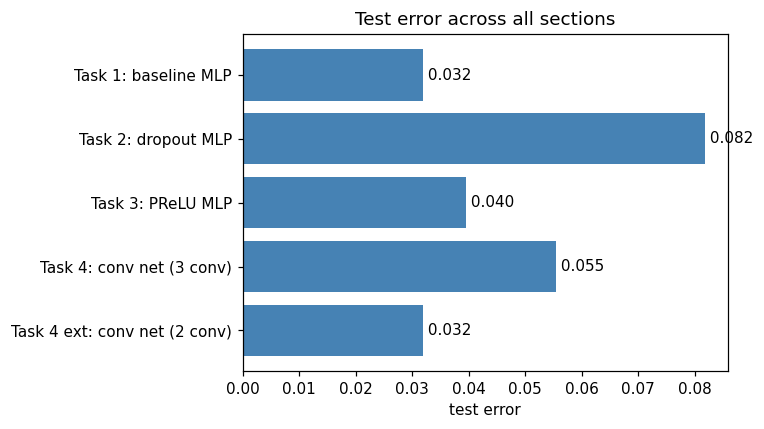

In [11]:
# ---- Overview table + chart ----
overview_rows = [
    ("Task 1: baseline MLP", baseline_test_error),
    ("Task 2: dropout MLP", dropout_test_error),
    ("Task 3: PReLU MLP", prelu_test_error),
    ("Task 4: conv net (3 conv)", cnn_test_error),
    ("Task 4 ext: conv net (2 conv)", cnn_variant_test_error),
]

print("Test-error overview")
print("=" * 46)
for _name, _err in overview_rows:
    print(f"{_name:<33s} {_err:6.4f}")

_fig, _ax = plt.subplots(figsize=(7, 4))
_labels = [row[0] for row in overview_rows]
_errors = [row[1] for row in overview_rows]
_ax.barh(range(len(overview_rows)), _errors, color="steelblue")
_ax.set_yticks(range(len(overview_rows)))
_ax.set_yticklabels(_labels)
_ax.invert_yaxis()
_ax.set_xlabel("test error")
_ax.set_title("Test error across all sections")
for _i, _err in enumerate(_errors):
    _ax.text(_err, _i, f" {_err:.3f}", va="center")
_fig.tight_layout()
plt.show()

<div style="color: green; font-weight: bold">Regarding 4.2, Sadly the provided solution did not do the task that your group did and neither did we :/. So i cannot give a good feedback here (I cant be bothered to run the whole model again on my laptop when it took 40min on the big PC to run...). However, for Task 4.1 I noticed that you did w_3 with 128x64x3x3 instead of 128x64x2x2. That might have caused the images of the 7 with the filters and conv. applied to look very different to the ones provided (your kernel gets bigger). Test and Training Errors look fine though, so your model did the correct stuff. Finally, you did not plot the losses over time but only the final results. That can make it hard to see if/when the model improved (the sample solution suggests that the loss drops sharply at the beginning which I only have to assume that yours did as well). But overall your model succeeded in solving the task, so I think all these points are just minor.</div>